# Student Alcohol Consumption Risk Classification
### Student Performance Dataset | Multi-Class Classification

Classify students into Low, Medium, or High alcohol consumption risk groups
based on demographic, family, social, and academic features.

**Dataset:** student-mat.csv — 395 students | 33 features
**Target:** alcohol_class (Low / Medium / High) — engineered from Dalc + Walc
**Approach:** CRISP-DM Methodology

## 0. Business Understanding

### Background
Alcohol consumption among students is a well-documented risk factor for poor academic
outcomes, mental health issues, and long-term wellbeing. Schools and universities want
to identify at-risk students early so support services can intervene before problems
escalate. However, students rarely self-report drinking habits to institutions directly.

### Business Problem
A school wellbeing department wants to predict which students are at risk of high
alcohol consumption using information already available from student records and
family surveys. This would allow the school to:
- Flag high-risk students for early pastoral care intervention
- Identify social and family factors most strongly associated with alcohol risk
- Design targeted awareness programmes for at-risk demographic groups

### ML Objective
Build a **multi-class classification model** that assigns each student to one of
three alcohol consumption risk levels — Low, Medium, or High — based on 28 features
covering demographics, family background, social behaviour, and academic performance.

The target variable `alcohol_class` is **engineered** from two raw columns:
- `Dalc` (workday alcohol consumption, scale 1–5)
- `Walc` (weekend alcohol consumption, scale 1–5)
- Combined average: Low = 1.0–2.0 | Medium = 2.1–3.5 | High = 3.6–5.0

### Success Criteria
- **Accuracy** and **CV Score** are the primary metrics
- Given class imbalance (Low=276, Medium=97, High=22), the model should be evaluated
  per-class using precision, recall and F1-score in the classification report
- A CV score above 70% on a 3-class imbalanced problem is considered strong

In [3]:
# Import core libraries for data manipulation, visualisation and numerical operations
# warnings suppressed to keep output clean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

## 1. Data Loading
Loading the Student Math dataset and previewing its structure.

In [7]:
# Load the student math performance dataset and preview the first few rows
df = pd.read_csv("student-mat.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Data Understanding
Exploring the dataset structure: checking column types, data quality and basic statistics.

### 2.1 Categorical Column Values
Verifying all categorical columns contain only expected values.
Unexpected values here would indicate data entry errors or encoding issues.

### 2.2 Wrong Data Type
Verifying all columns have the correct data types.
Categorical columns should be object, numeric columns should be int64.

In [9]:
# Check categorical columns for invalid values
cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup',
            'famsup', 'paid', 'activities', 'nursery',
            'higher', 'internet', 'romantic']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

school: ['GP' 'MS']
sex: ['F' 'M']
address: ['U' 'R']
famsize: ['GT3' 'LE3']
Pstatus: ['A' 'T']
Mjob: ['at_home' 'health' 'other' 'services' 'teacher']
Fjob: ['teacher' 'other' 'services' 'health' 'at_home']
reason: ['course' 'other' 'home' 'reputation']
guardian: ['mother' 'father' 'other']
schoolsup: ['yes' 'no']
famsup: ['no' 'yes']
paid: ['no' 'yes']
activities: ['no' 'yes']
nursery: ['yes' 'no']
higher: ['yes' 'no']
internet: ['no' 'yes']
romantic: ['no' 'yes']


### 2.2 Data Types
Verifying all columns have the correct data types.
Categorical columns should be object, numeric columns should be int64.

In [17]:
# Check data types — categorical columns should be object, numeric should be int64
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

### 2.3 Duplicate Values
Checking for repeated rows in the dataset.

In [21]:
# Count duplicate rows — any non-zero result requires investigation before modelling
df.duplicated().sum()

np.int64(0)

### 2.4 Null Values
Checking for missing values across all 33 columns.

In [25]:
# Check for missing values across all 33 columns
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

### 2.5 Outlier Detection (IQR Method)
Using the IQR method to identify outliers in all numeric columns.
Note: Columns like failures, famrel, freetime, Dalc, Walc use a fixed 1-5 scale
so their "outliers" are valid data points and will NOT be capped.

age         : outliers = 1  |  bounds = [13.00, 21.00]
Medu        : outliers = 0  |  bounds = [-1.00, 7.00]
Fedu        : outliers = 2  |  bounds = [0.50, 4.50]
traveltime  : outliers = 8  |  bounds = [-0.50, 3.50]
studytime   : outliers = 27  |  bounds = [-0.50, 3.50]
failures    : outliers = 83  |  bounds = [0.00, 0.00]
famrel      : outliers = 26  |  bounds = [2.50, 6.50]
freetime    : outliers = 19  |  bounds = [1.50, 5.50]
goout       : outliers = 0  |  bounds = [-1.00, 7.00]
Dalc        : outliers = 18  |  bounds = [-0.50, 3.50]
Walc        : outliers = 0  |  bounds = [-2.00, 6.00]
health      : outliers = 0  |  bounds = [0.00, 8.00]
absences    : outliers = 15  |  bounds = [-12.00, 20.00]
G1          : outliers = 0  |  bounds = [0.50, 20.50]
G2          : outliers = 13  |  bounds = [3.00, 19.00]
G3          : outliers = 0  |  bounds = [-1.00, 23.00]


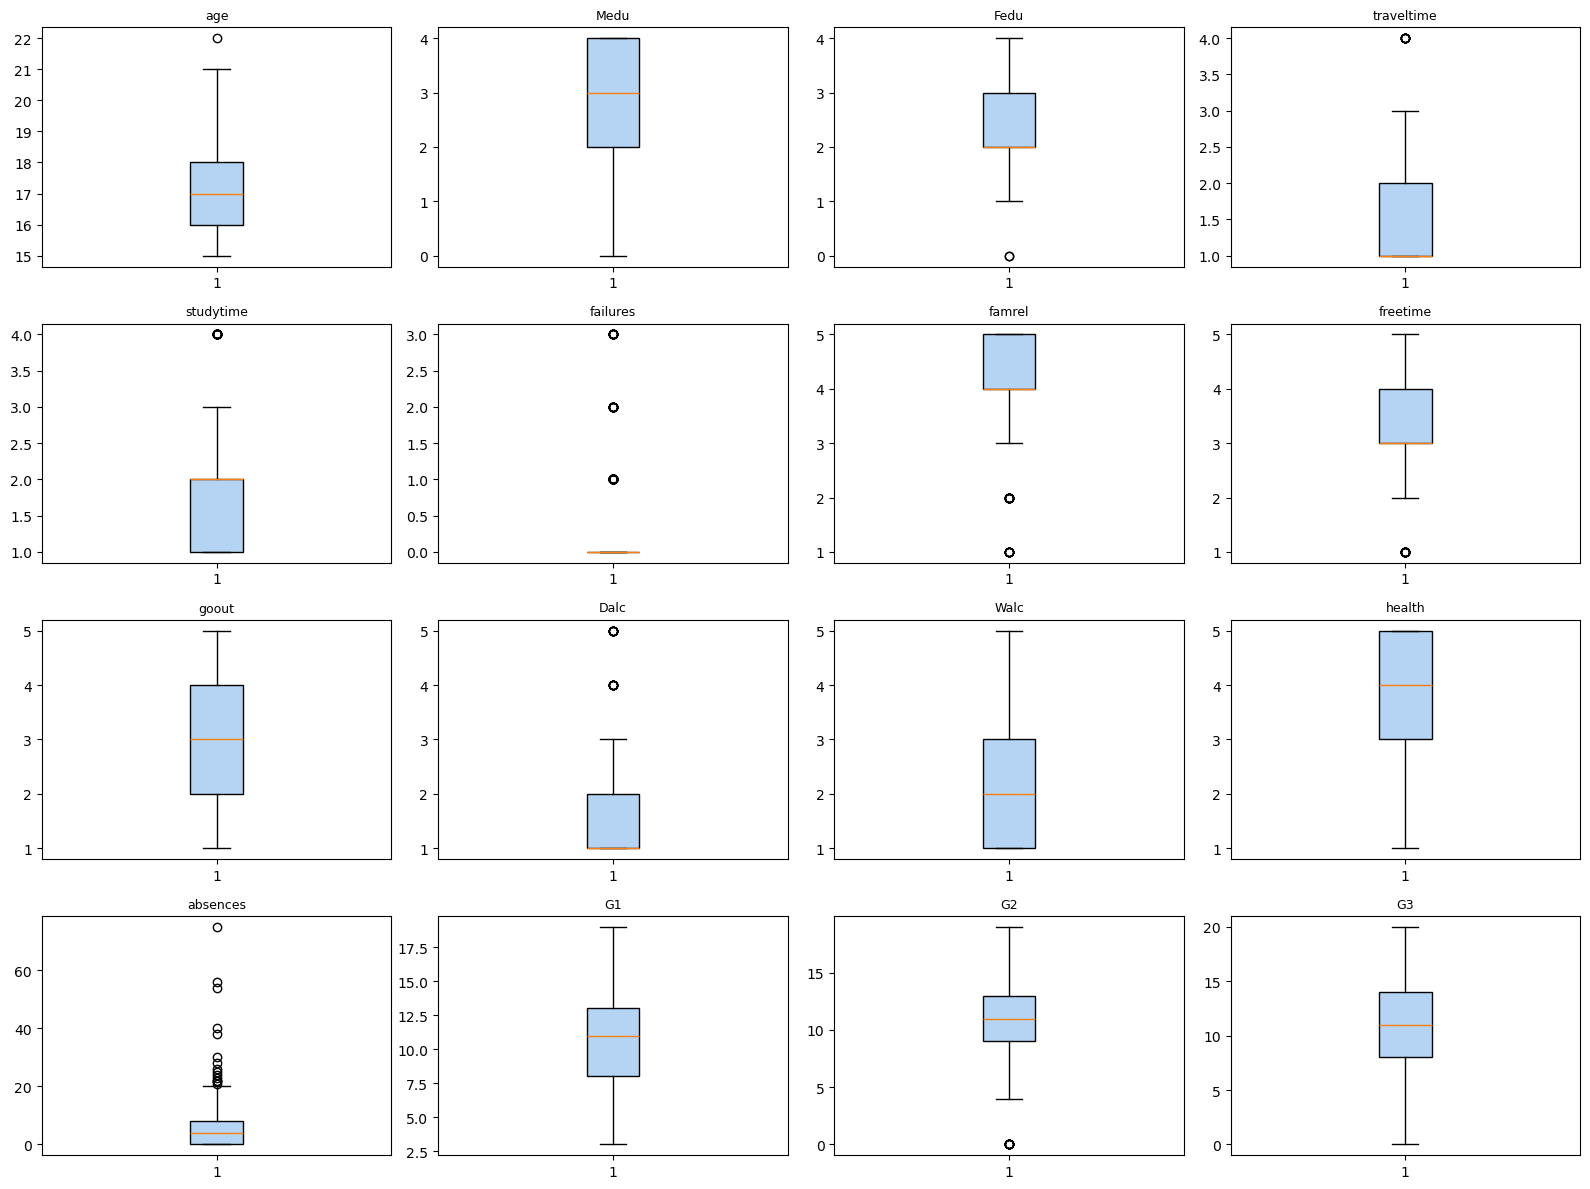

In [27]:
import matplotlib.pyplot as plt

num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime',
            'failures', 'famrel', 'freetime', 'goout',
            'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

# Check outliers using IQR
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:<12}: outliers = {n_out}  |  bounds = [{lower:.2f}, {upper:.2f}]")

# Boxplot to visualize
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor="#B5D4F4"))
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

### 2.6 Outlier Treatment
Only capping columns where outliers are genuine data issues:
- absences: some students have unusually high absences
- G2: possible data entry errors
- Fedu: minor outliers
- age: one student is unusually old

In [29]:
# Only cap these columns
cap_cols = ['absences', 'G2', 'Fedu', 'age']

for col in cap_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: capped {n_out} outlier(s) to [{lower:.2f}, {upper:.2f}]")

print("\nDone! Shape:", df.shape)

absences: capped 15 outlier(s) to [-12.00, 20.00]
G2: capped 13 outlier(s) to [3.00, 19.00]
Fedu: capped 2 outlier(s) to [0.50, 4.50]
age: capped 1 outlier(s) to [13.00, 21.00]

Done! Shape: (395, 33)


## 3. Feature Engineering

### 3.1 Create Target Variable
Combining Dalc (workday) and Walc (weekend) alcohol scores into one average score.
Converting the average into 3 classes:
- Low:    1.0 – 2.0
- Medium: 2.1 – 3.5
- High:   3.6 – 5.0

In [31]:
# Combine Dalc and Walc into one alcohol score
df['alcohol'] = (df['Dalc'] + df['Walc']) / 2

# Convert to 3 classes
# Low = 1.0 - 2.0
# Medium = 2.1 - 3.5
# High = 3.6 - 5.0
df['alcohol_class'] = pd.cut(df['alcohol'],
                              bins=[0, 2.0, 3.5, 5.0],
                              labels=['Low', 'Medium', 'High'])

print(df['alcohol_class'].value_counts())
print("\nSample:")
print(df[['Dalc', 'Walc', 'alcohol', 'alcohol_class']].head(10))

alcohol_class
Low       276
Medium     97
High       22
Name: count, dtype: int64

Sample:
   Dalc  Walc  alcohol alcohol_class
0     1     1      1.0           Low
1     1     1      1.0           Low
2     2     3      2.5        Medium
3     1     1      1.0           Low
4     1     2      1.5           Low
5     1     2      1.5           Low
6     1     1      1.0           Low
7     1     1      1.0           Low
8     1     1      1.0           Low
9     1     1      1.0           Low


### 3.2 Drop Unnecessary Columns
Dropping source alcohol columns (Dalc, Walc) and grades (G1, G2, G3).
Grades are academic outcomes — not related to predicting alcohol consumption.

In [33]:
# Drop Dalc, Walc and alcohol since they were used to create target
# Drop G1, G2, G3 — grades are not related to alcohol consumption prediction
df = df.drop(columns=['Dalc', 'Walc', 'alcohol', 'G1', 'G2', 'G3'])

print("Shape after drop:", df.shape)
print(df.columns.tolist())

Shape after drop: (395, 29)
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'alcohol_class']


### 3.3 Label Encoding
Converting all categorical columns to numeric using LabelEncoder.
Each unique category gets a unique integer (e.g. yes=1, no=0).
Target variable alcohol_class is also encoded: High=0, Low=1, Medium=2.

In [35]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup',
            'famsup', 'paid', 'activities', 'nursery',
            'higher', 'internet', 'romantic']

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Encode target variable
df['alcohol_class'] = le.fit_transform(df['alcohol_class'])

print("Encoding done!")
print(df.head())
print("\nTarget classes:")
print(df['alcohol_class'].value_counts())

Encoding done!
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4   4.0     0     4  ...   
1       0    0   17        1        0        1     1   1.0     0     2  ...   
2       0    0   15        1        1        1     1   1.0     0     2  ...   
3       0    0   15        1        0        1     4   2.0     1     3  ...   
4       0    0   16        1        0        1     3   3.0     2     2  ...   

   nursery  higher  internet  romantic  famrel  freetime  goout  health  \
0        1       1         0         0       4         3      4       3   
1        0       1         1         0       5         3      3       3   
2        1       1         1         0       4         3      2       3   
3        1       1         1         1       3         2      2       5   
4        1       1         0         0       4         3      2       5   

   absences  alcohol_class  
0         6              1  
1

### 3.4 Feature Scaling
Applying StandardScaler to all 28 features.
Converts each feature to mean=0 and std=1 so no single feature dominates the model.

In [37]:
# Separate features (X) from target (y)
# Apply StandardScaler — normalises all features to mean=0, std=1
# fit_transform on full X here as split happens next
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['alcohol_class'])
y = df['alcohol_class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Scaling done!
X shape: (395, 28)
y shape: (395,)


### 3.5 Train Test Split
Splitting data into 80% training and 20% testing sets.
stratify=y ensures all 3 alcohol classes are proportionally represented in both sets.
This is important because the dataset is imbalanced (Low=276, Medium=97, High=22).

In [39]:
# Split into train (80%) and test (20%) sets
# stratify=y ensures class proportions are preserved in both sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())

X_train: (316, 28)
X_test : (79, 28)
y_train: (316,)
y_test : (79,)

Class distribution in y_train:
alcohol_class
1    221
2     77
0     18
Name: count, dtype: int64

Class distribution in y_test:
alcohol_class
1    55
2    20
0     4
Name: count, dtype: int64


## 4. Modelling
Importing all required classifiers and evaluation metrics.
8 models will be trained and compared using Train Accuracy, CV Score, and Test Accuracy.

In [43]:
# Import all classifiers and evaluation utilities needed for the modelling section
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

### 4.1 Logistic Regression
Baseline linear classifier for multiclass classification.
class_weight='balanced' is NOT used here — results compared as-is with other models.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

# Train accuracy
ypred_train = log_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, ypred_train))

# Cross validation
cv_score = cross_val_score(log_model, X_train, y_train, cv=5, scoring="accuracy").mean()
print("CV Score     :", round(cv_score, 4))

# Test accuracy
ypred_test = log_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, ypred_test))

Train Accuracy: 0.7911392405063291
CV Score     : 0.6995
Test Accuracy: 0.7341772151898734


### 4.1.1 Evaluation — Logistic Regression
Confusion matrix and classification report for Logistic Regression.

In [47]:
# Print confusion matrix and full classification report for the evaluated model
# Report shows precision, recall and F1-score per class
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,ypred_test))

from sklearn.metrics import classification_report
print(classification_report(y_test,ypred_test))

[[ 1  1  2]
 [ 1 52  2]
 [ 4 11  5]]
              precision    recall  f1-score   support

           0       0.17      0.25      0.20         4
           1       0.81      0.95      0.87        55
           2       0.56      0.25      0.34        20

    accuracy                           0.73        79
   macro avg       0.51      0.48      0.47        79
weighted avg       0.71      0.73      0.71        79



### 4.2 K-Nearest Neighbors (KNN)
Distance based classifier. GridSearchCV used to find best n_neighbors (1-10)
and distance metric p (1=Manhattan, 2=Euclidean).

In [61]:
#Hyperparameter Tuning
estimator = KNeighborsClassifier()
param_grid = {"n_neighbors":list(range(1,10)),"p":[1,2]}
knn_grid = GridSearchCV(estimator, param_grid,scoring="accuracy",cv=5)
knn_grid.fit(X_train,y_train)

#KNN with best Hyperparametres
knn_grid.best_estimator_

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [63]:
#Modelling
knn_model = knn_grid.best_estimator_
knn_model.fit(X_train,y_train)

#predict And evaluate on Train Data
ypred_train = knn_model.predict(X_train)
print("Train Accuracy:",accuracy_score(y_train,ypred_train))

#cross Validation Score
print("CV score:",cross_val_score(knn_model,X_train,y_train,cv=5,scoring="accuracy").mean())

#predict and evaluate
ypred_test=knn_model.predict(X_test)
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.740506329113924
CV score: 0.7057539682539684
Test Accuracy: 0.6835443037974683


### 4.3 Support Vector Machine (SVM)
Finds the optimal hyperplane to separate 3 alcohol classes.
GridSearchCV tunes C (regularization strength) and kernel type.

In [66]:
from sklearn.svm import SVC
estimator = SVC(random_state=True)
param_grid={"C":[0.01,0.1,1],"kernel":["linear","rbf","sigmoid","poly"]}
svm_grid=GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)
svm_grid.fit(X_train,y_train)

#SVM with best Hyperparamters
svm_grid.best_estimator_

,C,1
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [68]:
#modelling
svm_model = svm_grid.best_estimator_
svm_model.fit(X_train,y_train)

# predict and Evaluate on train data
ypred_train = svm_model.predict(X_train)
print("Train Accuracy:",accuracy_score(y_train,ypred_train))

#cross Validation on Train data
print("CV Score:",cross_val_score(svm_model,X_train,y_train,cv=5,scoring="accuracy").mean())

#predict and Evaluate on test data
ypred_test = svm_model.predict(X_test)
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.8575949367088608
CV Score: 0.7311011904761905
Test Accuracy: 0.6962025316455697


### 4.4 Decision Tree Classifier
Tree based model trained first without tuning to check default depth,
then tuned with GridSearchCV using criterion (gini/entropy) and max_depth.
Feature importance extracted to select only relevant features.

In [75]:
# Fit a baseline Decision Tree on the training data before hyperparameter tuning
model = DecisionTreeClassifier(random_state=True)
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,True
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
# Print tree depth to understand model complexity before pruning/tuning
print(model.get_depth())

13


In [79]:
#hyperparameter Tuning
estimator = DecisionTreeClassifier(random_state=True)
param_grid={"criterion":["gini","entropy"],
            "max_depth":list(range(1,13))}
dt_grid = GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)
dt_grid.fit(X_train,y_train)

dt= dt_grid.best_estimator_
dt

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,True
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4.4.1 AUC Score — Decision Tree
Using multi_class='ovr' (One vs Rest) since this is a 3-class problem.
predict_proba returns probabilities for all 3 classes.

In [81]:
# Compute multi-class AUC using One-vs-Rest strategy
# predict_proba returns probability scores needed for AUC calculation
from sklearn.metrics import roc_auc_score

y_prob_dt = dt.predict_proba(X_test)

print("AUC Score:", roc_auc_score(y_test, y_prob_dt, multi_class="ovr"))

AUC Score: 0.7572633110768704


### 4.4.2 Feature Importance — Decision Tree
Extracting features with importance > 0.
Only features that contribute to the model are kept for retraining.

In [83]:
#Important features
feats_ab = pd.DataFrame(data=dt.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_dt = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_dt

['sex', 'Medu', 'goout']

### 4.4.3 Retrain Decision Tree with Important Features
Converting X_train and X_test to DataFrames first (required for column name selection).
Retraining the best Decision Tree estimator on selected features only.

In [132]:
# Convert scaled arrays back to DataFrames to enable column-name-based feature selection
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

X_train_dt = X_train_df[important_features_dt]
X_test_dt  = X_test_df[important_features_dt]

dt = dt_grid.best_estimator_
dt.fit(X_train_dt, y_train)

print("Train Accuracy:", accuracy_score(y_train, dt.predict(X_train_dt)))
print("CV Score      :", round(cross_val_score(dt, X_train_dt, y_train, cv=5, scoring='accuracy').mean(), 4))
print("Test Accuracy :", accuracy_score(y_test, dt.predict(X_test_dt)))

Train Accuracy: 0.7436708860759493
CV Score      : 0.7439
Test Accuracy : 0.7468354430379747


### 4.5 Random Forest Classifier
Ensemble of decision trees using bagging. Tuned with GridSearchCV on n_estimators.
class_weight='balanced' used to handle class imbalance (High class has only 22 samples).
Feature importance extracted and only features with importance > 0 are kept.

In [86]:
#Hyperparameter Tuning
estimator = RandomForestClassifier(random_state=True)

param_grid = {"n_estimators":list(range(1,20))}

rf_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
rf_grid.fit(X_train,y_train)

rf=rf_grid.best_estimator_
rf

,n_estimators,18
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
#Important features
feats_ab = pd.DataFrame(data=rf.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_rf = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_rf

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'health',
 'absences']

In [92]:
import pandas as pd

# Convert back to dataframe with column names
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

# Select important features
X_train_rf = X_train_df[important_features_rf]
X_test_rf  = X_test_df[important_features_rf]

# Random Forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_rf, y_train)

ypred_train = rf.predict(X_train_rf)
print("Train Accuracy:", accuracy_score(y_train, ypred_train))

cv_score = cross_val_score(rf, X_train_rf, y_train, cv=5, scoring='accuracy').mean()
print("CV Score      :", round(cv_score, 4))

ypred_test = rf.predict(X_test_rf)
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

Train Accuracy: 1.0
CV Score      : 0.712
Test Accuracy : 0.7088607594936709


### 4.6 AdaBoost Classifier
Boosting ensemble that focuses more on misclassified samples each iteration.
GridSearchCV tunes n_estimators (1-100).

In [94]:
#Hyperparameter Tuning
estimator = AdaBoostClassifier(random_state=True)
param_grid = {"n_estimators":list(range(1,100))}

ab_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
ab_grid.fit(X_train,y_train)

ab=ab_grid.best_estimator_
ab

,estimator,None
,n_estimators,4
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,True


In [96]:
#Important features
feats_ab = pd.DataFrame(data=ab.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_ab = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_ab

['sex', 'goout']

In [100]:
import pandas as pd

# Convert to dataframe
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

# Select important features
X_train_ab = X_train_df[important_features_ab]
X_test_ab  = X_test_df[important_features_ab]

# Modelling
ab = ab_grid.best_estimator_
ab.fit(X_train_ab, y_train)

ypred_train = ab.predict(X_train_ab)
ypred_test  = ab.predict(X_test_ab)

print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("CV Score      :", cross_val_score(ab, X_train_ab, y_train, cv=5, scoring='accuracy').mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

Train Accuracy: 0.7436708860759493
CV Score      : 0.7438988095238095
Test Accuracy : 0.7468354430379747


### 4.7 Gradient Boosting Classifier
Sequential ensemble that minimizes loss by adding weak learners one at a time.
GridSearchCV tunes both n_estimators and learning_rate.

In [107]:
#Hyperparameter Tuning
estimator = GradientBoostingClassifier(random_state=True)
param_grid = {"n_estimators":list(range(1,30)),
             "learning_rate":[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]}

gb_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
gb_grid.fit(X_train,y_train)

gb=gb_grid.best_estimator_
gb

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,9
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [109]:
#Important features
feats_gb = pd.DataFrame(data=gb.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_gb = feats_gb[feats_gb["Importance"]>0].index.tolist()
important_features_gb

['sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'famsup',
 'activities',
 'higher',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'health',
 'absences']

In [113]:
import pandas as pd

# Convert to dataframe
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

# Select important features
X_train_gb = X_train_df[important_features_gb]
X_test_gb  = X_test_df[important_features_gb]

# Modelling
gb = gb_grid.best_estimator_
gb.fit(X_train_gb, y_train)

ypred_train = gb.predict(X_train_gb)
ypred_test  = gb.predict(X_test_gb)

print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("CV Score      :", cross_val_score(gb, X_train_gb, y_train, cv=5, scoring='accuracy').mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

Train Accuracy: 0.7943037974683544
CV Score      : 0.7184523809523811
Test Accuracy : 0.7088607594936709


### 4.8 XGBoost Classifier
Optimized gradient boosting with regularization to prevent overfitting.
Tuned with n_estimators, max_depth, and gamma.

In [116]:
#Hyperparameter Tuning
estimator = XGBClassifier()
param_grid = {"n_estimators":[10,20,40,100],
              "max_depth":[3,4,5],
             "gamma":[0,0.15,0.3,0.5,1]}

xgb_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
xgb_grid.fit(X_train,y_train)

xgb=xgb_grid.best_estimator_
xgb

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [120]:
#Important features
feats_xgb = pd.DataFrame(data=xgb.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_xgb = feats_xgb[feats_xgb["Importance"]>0].index.tolist()
important_features_xgb

['sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'traveltime',
 'studytime',
 'failures',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'health',
 'absences']

In [122]:
# Convert scaled arrays to DataFrames to enable column-name-based feature selection for XGBoost

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

In [124]:
# Select only the important features identified from XGBoost feature importances
# Fit final XGBoost model and evaluate on train and test sets
X_train_xgb = X_train_df[important_features_xgb]
X_test_xgb  = X_test_df[important_features_xgb]

xgb = xgb_grid.best_estimator_
xgb.fit(X_train_xgb, y_train)

ypred_train = xgb.predict(X_train_xgb)
ypred_test  = xgb.predict(X_test_xgb)

print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("CV Score      :", cross_val_score(xgb, X_train_xgb, y_train, cv=5, scoring='accuracy').mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

Train Accuracy: 0.8164556962025317
CV Score      : 0.7058035714285715
Test Accuracy : 0.7468354430379747


## 5. Final Evaluation — Best Model (Decision Tree)
Decision Tree selected as best model based on highest CV Score (74.3%) with no overfitting.
Evaluating on test set with confusion matrix and classification report.

In [134]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ypred_test = dt.predict(X_test_dt)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, ypred_test))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, ypred_test, 
      target_names=['High', 'Low', 'Medium']))

Confusion Matrix:
[[ 0  1  3]
 [ 0 50  5]
 [ 0 11  9]]

Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.81      0.91      0.85        55
      Medium       0.53      0.45      0.49        20

    accuracy                           0.75        79
   macro avg       0.45      0.45      0.45        79
weighted avg       0.70      0.75      0.72        79



## 6. Prediction on New Students
Applying the trained Decision Tree model to predict alcohol consumption
for 2 new unseen students using the same preprocessing pipeline.

Encoding reference used during training:
- High   → 0
- Low    → 1
- Medium → 2

In [144]:
import numpy as np
import pandas as pd

# New student data
new_data = pd.DataFrame({
    'school':     [0, 1],
    'sex':        [0, 1],
    'age':        [17, 18],
    'address':    [1, 0],
    'famsize':    [0, 1],
    'Pstatus':    [1, 0],
    'Medu':       [3, 2],
    'Fedu':       [2, 1],
    'Mjob':       [2, 3],
    'Fjob':       [1, 2],
    'reason':     [0, 1],
    'guardian':   [0, 1],
    'traveltime': [1, 2],
    'studytime':  [2, 1],
    'failures':   [0, 1],
    'schoolsup':  [0, 1],
    'famsup':     [1, 0],
    'paid':       [0, 1],
    'activities': [1, 0],
    'nursery':    [1, 0],
    'higher':     [1, 0],
    'internet':   [1, 0],
    'romantic':   [0, 1],
    'famrel':     [4, 2],
    'freetime':   [3, 4],
    'goout':      [2, 4],
    'health':     [3, 2],
    'absences':   [2, 8]
})

# Scale all 28 features first
new_data_scaled = scaler.transform(new_data)
new_data_scaled = pd.DataFrame(new_data_scaled, columns=X.columns)

# Then select decision tree features
new_data_dt = new_data_scaled[important_features_dt]

# Predict
predictions = dt.predict(new_data_dt)

class_map = {0: 'High', 1: 'Low', 2: 'Medium'}

print("Predictions:")
for i, pred in enumerate(predictions):
    print(f"  Student {i+1}: {class_map[pred]} alcohol consumption")

Predictions:
  Student 1: Low alcohol consumption
  Student 2: Medium alcohol consumption
